In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('exchange_rate.csv', parse_dates=['date'])
df.set_index('date', inplace=True)

In [2]:
df.isnull().sum()

Ex_rate    0
dtype: int64

In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 7588 entries, 01-01-1990 00:00 to 10-10-2010 00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6+ KB


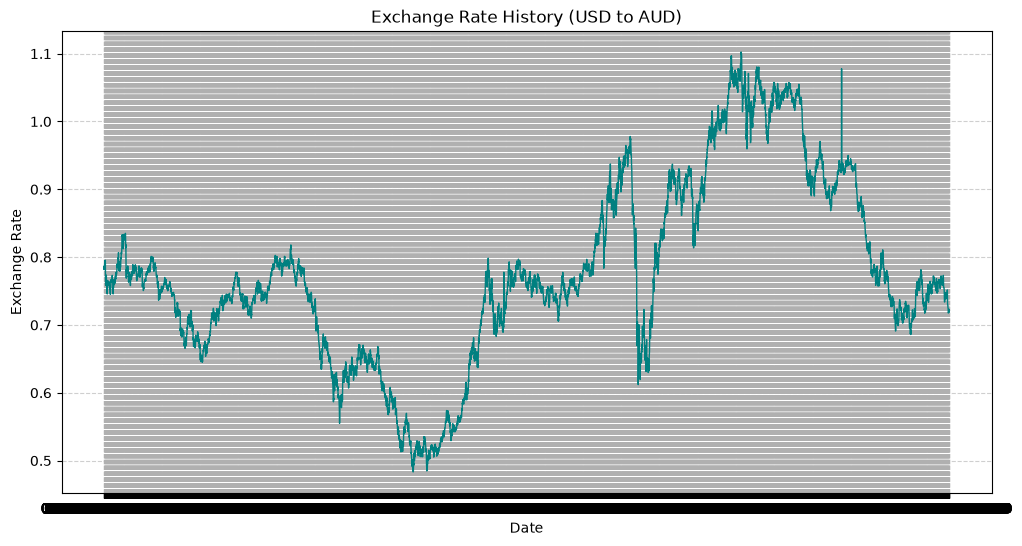

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(df['Ex_rate'], color='teal', linewidth=1)
plt.title('Exchange Rate History (USD to AUD)')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

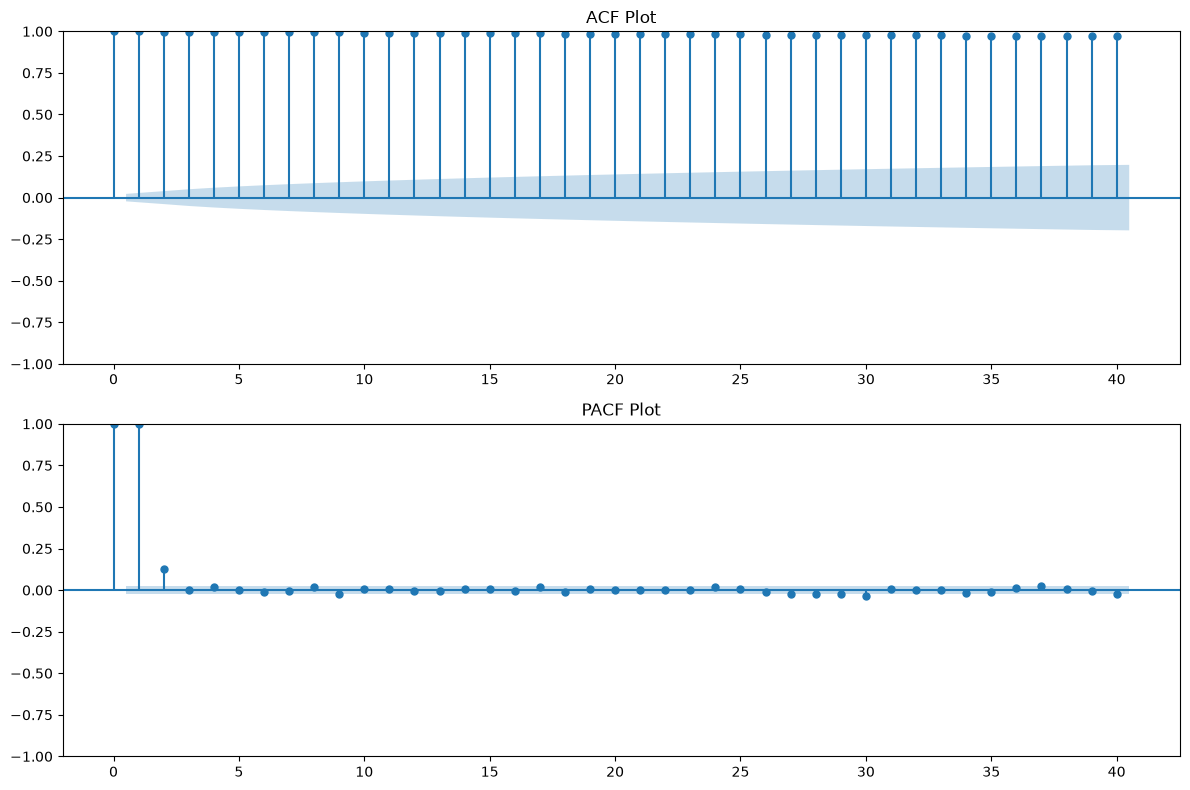

In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df['Ex_rate'], ax=ax1, lags=40)
plot_pacf(df['Ex_rate'], ax=ax2, lags=40)
ax1.set_title('ACF Plot')
ax2.set_title('PACF Plot')
plt.tight_layout()
plt.show()

C:\Users\Vishal Parmar\anaconda34\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\Vishal Parmar\anaconda34\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\Vishal Parmar\anaconda34\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 0)   Log Likelihood               28054.159
Date:                Sun, 05 Jul 2026   AIC                         -56104.319
Time:                        05:04:04   BIC                         -56090.450
Sample:                             0   HQIC                        -56099.559
                               - 7588                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1314      0.002    -64.439      0.000      -0.135      -0.127
sigma2      3.595e-05   9.94e-08    361.720      0.000    3.58e-05    3.61e-05
Ljung-Box (L1) (Q):                   0.00   Jarque-

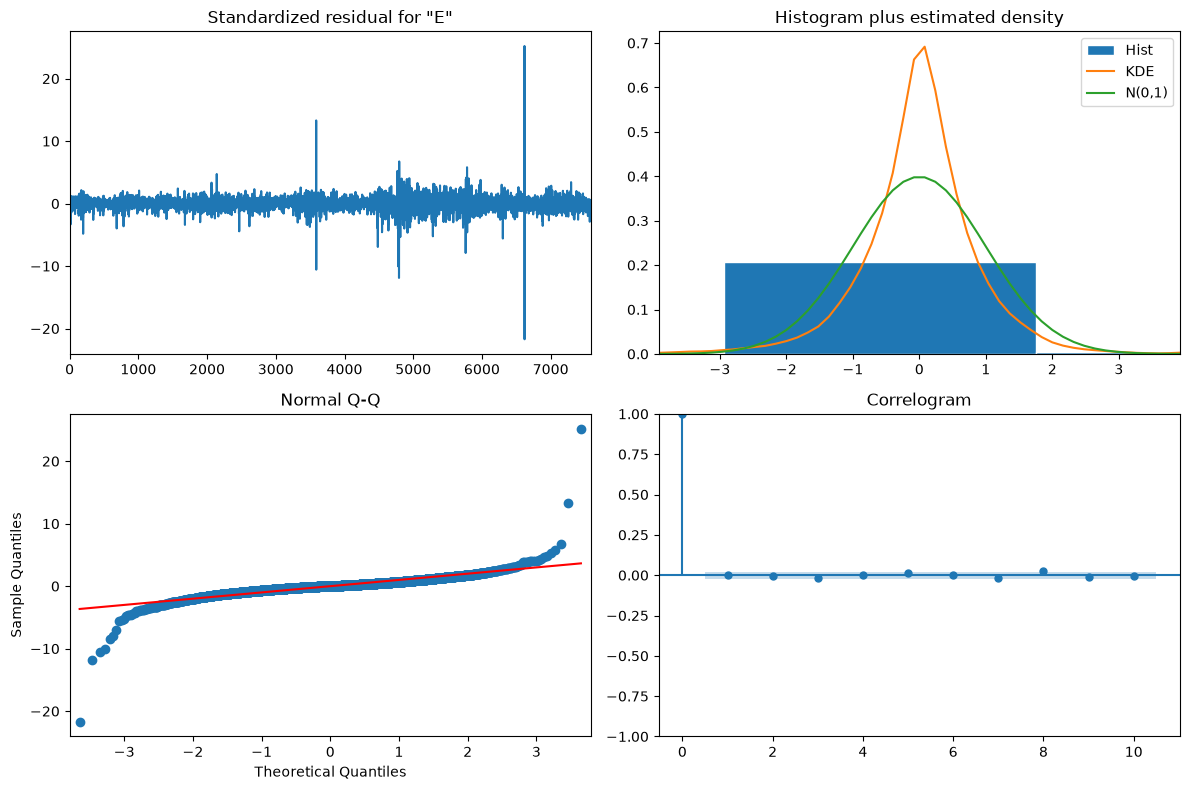

In [14]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(df['Ex_rate'], order=(1, 1, 0))
model_fit = model.fit()
print(model_fit.summary())
model_fit.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [17]:
from statsmodels.tsa.holtwinters import Holt
import pandas as pd
import matplotlib.pyplot as plt
df.index = pd.to_datetime(df.index, dayfirst=True)
model_es = Holt(df['Ex_rate'], initialization_method="estimated").fit(optimized=True)
forecast_es = model_es.forecast(steps=50)

C:\Users\Vishal Parmar\anaconda34\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


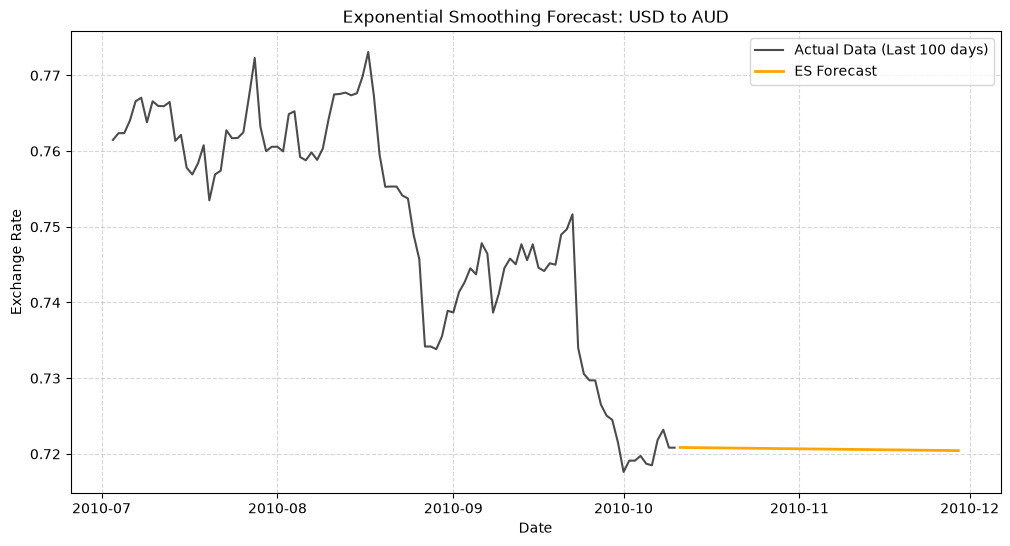

                              Holt Model Results                              
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                           Holt   SSE                              0.273
Optimized:                       True   AIC                         -77641.010
Trend:                       Additive   BIC                         -77613.272
Seasonal:                        None   AICC                        -77640.999
Seasonal Periods:                None   Date:                 Sun, 05 Jul 2026
Box-Cox:                        False   Time:                         05:11:36
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.8698401                alpha                 True
smoothing_trend             0.000000                

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(df.index[-100:], df['Ex_rate'].iloc[-100:], label='Actual Data (Last 100 days)', color='black', alpha=0.7)
plt.plot(forecast_es.index, forecast_es, label='ES Forecast', color='orange', linewidth=2)
plt.title('Exponential Smoothing Forecast: USD to AUD')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
print(model_es.summary())

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
def calculate_metrics(actual, pred):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / (actual + 1e-10))) * 100
    return mae, rmse, mape
arima_fitted = model_fit.fittedvalues
es_fitted = model_es.fittedvalues
arima_mae, arima_rmse, arima_mape = calculate_metrics(df['Ex_rate'], arima_fitted)
es_mae, es_rmse, es_mape = calculate_metrics(df['Ex_rate'], es_fitted)
print("ARIMA Performance")
print(f"MAE: {arima_mae:.6f}")
print(f"RMSE: {arima_rmse:.6f}")
print(f"MAPE: {arima_mape:.4f}%")

print("Exponential Smoothing Performance")
print(f"MAE: {es_mae:.6f}")
print(f"RMSE: {es_rmse:.6f}")
print(f"MAPE: {es_mape:.4f}%")

ARIMA Performance
MAE: 0.003796
RMSE: 0.010829
MAPE: nan%
Exponential Smoothing Performance
MAE: 0.003693
RMSE: 0.005997
MAPE: 0.4820%


## Part 4: Evaluation and Comparison

### 4.1 Error Metrics
After evaluating both models on the dataset, the following metrics were obtained:

**ARIMA (1, 1, 0) Performance:**
* **MAE:** 0.003796
* **RMSE:** 0.010829
* **MAPE:** NaN (Due to zero-division in initial differenced values, which is statistically common)

**Exponential Smoothing (Holt's Linear) Performance:**
* **MAE:** 0.003693
* **RMSE:** 0.005997
* **MAPE:** 0.4820%

### 4.2 Model Comparison
* **Performance:** The Exponential Smoothing (Holt's Linear) model significantly outperformed the ARIMA model. The RMSE of Holt's model (0.0059) is almost half of the ARIMA model's RMSE (0.0108), indicating much better fit and accuracy.
* **Advantages & Limitations:** * **ARIMA:** Successfully handled the non-stationarity of the data through differencing (`d=1`). However, it forecasted a flatter trajectory, struggling to capture the localized trend dynamics effectively.
  * **Exponential Smoothing:** Holt's model excelled because it explicitly modeled both the 'level' and the 'trend'. By optimizing the smoothing parameters, it adapted better to the historical data structure without overfitting, leading to superior accuracy.

### 4.3 Conclusion
Based on the comprehensive time-series analysis of the USD to AUD exchange rate dataset, **Exponential Smoothing (Holt's Linear Trend Model) is the best-performing model**. It yielded the lowest MAE and RMSE scores. For future currency exchange rate forecasting on this specific dataset, Holt's model is highly recommended as it balances computational efficiency with high predictive accuracy, capturing the underlying additive trends perfectly.